# 03b — Pre-Event State Conditioning — NQ

## Research question

Notebook 02 estimated the **unconditional** response of ES futures to macroeconomic surprises.
CPI is the only strong signal: a 1-SD hotter headline print lowers ES by roughly 18–24 bps.

This notebook asks:

> **Does the market's state *before* the release change how ES responds to the *same* surprise?**

If it does, a strategy can scale or filter trades by state (Notebook 04). If it does not, that is also a result: the surprise-only model is the right benchmark.

> **03b — E-mini Nasdaq-100 (NQ).** This notebook is Notebook 03 (ES) run on **NQ**, with identical code and parameters.
> - Prices: Jack Duncan's cleaned 1-minute file `futures_1min_clean_v3_NQ.parquet` (team repo), roll-adjusted the same way. The variables `es` / `es_adj` hold **NQ** bars (names kept from the ES notebook).
> - Costs: 2 ticks + $4.50 per round trip on the NQ contract (tick 0.25, $20 per point).
> - Outputs are saved as `nb03b_NQ_*` (results, figures) and `event_state_features_2016_2026_NQ.parquet`, so nothing from the ES notebook is overwritten.
> - **Text cells are copied from the ES notebook.** Where they quote ES numbers or say "ES", they describe the ES study; the NQ results are in the outputs.
> - Run order: 03b → 04b → 05b → 06b for the same market (each reads the previous one's files).

## Notebook Workflow

| Step | What happens | Output |
|---|---|---|
| 1 | Setup, paths, pre-registered parameters | — |
| 2 | Load NB02 event data, build the signed surprise `x` | event table |
| 3 | Load ES 1-minute data, roll-adjust the continuous contract | adjusted log price |
| 4 | Daily close and daily state features | `rv_20d`, `mom_20d`, `dd_60d`, … |
| 5 | Event-level state features and no-look-ahead checks | state table |
| 6 | Post-release drift returns (the tradeable part) | `drift_{h}m_bps` |
| 7 | State descriptives | correlations, bucket balance |
| 8 | Bucket analysis: surprise beta in Low / Mid / High states | `nb03_bucket_betas.csv` |
| 9 | Interaction regressions | `nb03_interaction_results.csv` |
| 10 | Permutation tests and multiple-testing (BH-FDR) correction | q-values |
| 11 | Subperiod stability (2016–2020 vs 2021–2026) | sign agreement |
| 12 | Does the state predict the **size** of the move? | `nb03_magnitude_results.csv` |
| 13 | Pre-registered selection rule, then hand-off to Notebook 04 | `nb03_state_selection.csv`, `event_state_features_2016_2026.parquet` |

## Methodology: design rules fixed *before* looking at results

1. **No look-ahead.** Every state variable for an event at time $T$ uses ES bars strictly before $T$. The last bar used is the $T-1$ bar, the same `pre_close` as in NB02. Daily features come from the 16:00 ET close of the previous trading day.
2. **Causal normalisation.** Each state is converted to a percentile against a **trailing 1-year** distribution ending before the event date. For intraday states the reference is measured at the **same clock time** (08:30 or 10:00 ET) every day. No full-sample z-scores or quantiles are used.
3. **Roll adjustment.** `ES.c.0` is an unadjusted continuous front-month series. Multi-day features use a roll-adjusted log price (1-minute returns across an `instrument_id` change are set to 0).
4. **Signed surprise.** One headline signal per family, signed by economic theory and NB02 so that $x>0$ means *good news for equities*:
   $x_{CPI} = -z_{headline\,CPI}$, $x_{PCE} = -z_{headline\,PCE}$, $x_{NFP} = +z_{payrolls}$. The sign is fixed, not re-estimated.
5. **Pre-registered states.** Six primary states, each with an economic hypothesis (table below). Everything else is labelled *exploratory*.
6. **Pre-registered targets.** `ret_5m_bps` (response including the instant jump) and `drift_30m_bps` (the post-release drift, which a strategy can actually trade).
7. **Multiple testing.** Benjamini–Hochberg FDR is applied across all interaction tests, together with a permutation test.

### Pre-registered state variables and hypotheses

| State | Definition (known before $T$) | Hypothesis |
|---|---|---|
| `rv_20d` | 20-day realised vol of daily closes (annualised %) | High-vol regimes → larger surprise beta (uncertainty, thinner liquidity) |
| `rv_pre_1d` | Realised vol of 5-min returns over the last ~23 trading hours (bps) | Short-term stress amplifies the reaction |
| `mom_20d` | 20-day log return (%) | After strong rallies, bad news hits harder (stretched positioning) |
| `dd_60d` | Distance from the 60-day high (%) | In drawdowns, the market is more sensitive to inflation news |
| `overnight_ret` | Prior 16:00 ET close → $T-1$ (bps) | A large pre-release move signals partial pre-positioning, so less left to react |
| `prev_x` | Previous signed surprise of the same family | Surprise streaks: a second hot print confirms the trend, so a larger response |

**Exploratory (reported, not used for selection):** `mom_5d`, `ma50_gap`, `rv_pre_60m`, `ret_pre_60m`.

## 1. Setup and Project Paths

In [1]:
from pathlib import Path
import sys
import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# ------------------------------------------------------------
# Project paths (same convention as NB01/NB02)
# ------------------------------------------------------------
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

MARKET = "NQ"                      # this notebook's market
TEAM_DATA = PROJECT_ROOT.parent / "blackrock-intraday" / "data" / "processed"
MARKET_FILE = TEAM_DATA / f"futures_1min_clean_v3_{MARKET}.parquet"   # Jack's cleaned 1-minute file
TICK, MULT = {f"{MARKET}": (0.25, 50.0), "NQ": (0.25, 20.0), "ZN": (1 / 64, 1000.0)}[MARKET]   # tick, $ per point
_BARS = {}
def load_market_minute():
    """1-minute bars of MARKET as [close, instrument_id] (loaded once, then cached).
    The variables `es` / `es_adj` below hold THIS market's bars (names kept from the ES notebook)."""
    if "bars" not in _BARS:
        import src.multi_asset as _ma
        _BARS["bars"] = _ma.load_bars(MARKET_FILE, "team_v3")
    return _BARS["bars"]

for d in [RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EVENT_MODEL_FILE = PROCESSED_DIR / "macro_event_model_data_2016_2026.parquet"

# Helper module
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import src.state_conditioning as sc
importlib.reload(sc)

print("Project root:", PROJECT_ROOT)
print("Event file exists:", EVENT_MODEL_FILE.exists())
print(f"{MARKET} raw file exists:", MARKET_FILE.exists())

Project root: /Users/reza/Desktop/mfe-term_3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises
Event file exists: True
NQ raw file exists: True


In [2]:
# ---- market switch: costs, titles --------------------------------------------
if "wf" in globals():                       # walk-forward costs use this market's contract
    wf.ES_TICK, wf.ES_MULTIPLIER = TICK, MULT
import re as _re, matplotlib.axes as _mx, matplotlib.figure as _mf
if not getattr(_mx.Axes.set_title, "_mkt", False):
    _T0_, _S0_ = _mx.Axes.set_title, _mf.Figure.suptitle
    def _set_title(self, label, *a, **k):
        return _T0_(self, _re.sub(r"\bES\b", MARKET, str(label)), *a, **k)
    def _suptitle(self, t, *a, **k):
        return _S0_(self, _re.sub(r"\bES\b", MARKET, str(t)), *a, **k)
    _set_title._mkt = True
    _mx.Axes.set_title, _mf.Figure.suptitle = _set_title, _suptitle
print(f"MARKET = {MARKET} | file: {MARKET_FILE.name} (exists: {MARKET_FILE.exists()}) | tick {TICK:g}, ${MULT:g} per point"
      f" | cost 2 ticks + $4.50 = {2 * TICK + 4.5 / MULT:.4f} points per round trip")

MARKET = NQ | file: futures_1min_clean_v3_NQ.parquet (exists: True) | tick 0.25, $20 per point | cost 2 ticks + $4.50 = 0.7250 points per round trip


### 1.1 Pre-registered parameters
These are fixed **before** any result is examined. Changing them after seeing results would invalidate the multiple-testing correction.

In [3]:
FAMILIES = ["CPI", "NFP", "PCE", "ALL"]          # ALL = pooled, family-specific slopes

PRIMARY_STATES = ["rv_20d", "rv_pre_1d", "mom_20d", "dd_60d", "overnight_ret", "prev_x"]
EXPLORATORY_STATES = ["mom_5d", "ma50_gap", "rv_pre_60m", "ret_pre_60m"]

RET_TARGETS = [f"ret_{h}m_bps" for h in sc.HORIZONS]            # from T-1 (NB02 definition)
DRIFT_TARGETS = [f"drift_{h}m_bps" for h in sc.DRIFT_HORIZONS]  # from T (tradeable)
ALL_TARGETS = RET_TARGETS + DRIFT_TARGETS

PRIMARY_TARGETS = ["ret_5m_bps", "drift_30m_bps"]

TRAILING_WINDOW_DAYS = 365   # percentile reference window
SPLIT_DATE = "2021-01-01"    # subperiod split: 2016-2020 vs 2021-2026
N_PERM = 2000                # permutations per primary test
FDR_Q = 0.10

print("Primary states:", PRIMARY_STATES)
print("Primary targets:", PRIMARY_TARGETS)

Primary states: ['rv_20d', 'rv_pre_1d', 'mom_20d', 'dd_60d', 'overnight_ret', 'prev_x']
Primary targets: ['ret_5m_bps', 'drift_30m_bps']


## 2. Load NB02 Event Data and Build the Signed Surprise

In [4]:
events = pd.read_parquet(EVENT_MODEL_FILE)
events["timestamp_utc"] = pd.to_datetime(events["timestamp_utc"], utc=True)
events = events.sort_values("timestamp_utc").reset_index(drop=True)

print("Event rows:", len(events))
print("Unique timestamps:", events["timestamp_utc"].nunique())
print("Range:", events["timestamp_utc"].min(), "to", events["timestamp_utc"].max())
display(events["event_type"].value_counts().rename("n_events").to_frame())
display(events.head())

assert events["timestamp_utc"].is_unique
assert set(RET_TARGETS).issubset(events.columns)

Event rows: 363
Unique timestamps: 363
Range: 2016-01-08 13:30:00+00:00 to 2026-06-25 12:30:00+00:00


,n_events
event_type,
NFP,122
CPI,122
PCE,119


,timestamp_utc,event_type,avg_hourly_earnings,core_cpi,core_pce,headline_cpi,headline_pce,nonfarm_payrolls,unemployment_rate,pre_close,ret_1m_bps,ret_5m_bps,ret_15m_bps,ret_30m_bps,ret_60m_bps
0,2016-01-08 13:30:00+00:00,NFP,-0.9769,NaN,NaN,NaN,NaN,1.6143,0.4340,"1,950.5000",34.5468,65.1551,26.8800,17.9280,-19.2443
1,2016-01-20 13:30:00+00:00,CPI,NaN,-1.0924,NaN,-0.8034,NaN,NaN,NaN,"1,843.0000",-2.7133,6.7801,-1.3566,9.4909,9.4909
2,2016-02-01 13:30:00+00:00,PCE,NaN,NaN,-1.3234,NaN,-1.3212,NaN,NaN,"1,915.5000",1.3051,-2.6106,14.3463,11.7394,19.5580
3,2016-02-05 13:30:00+00:00,NFP,1.6753,NaN,NaN,NaN,NaN,-0.5663,-0.2453,"1,909.0000",-32.7934,-59.1057,-39.3650,-52.5211,-23.6004
4,2016-02-19 13:30:00+00:00,CPI,NaN,1.4020,NaN,1.1648,NaN,NaN,NaN,"1,910.5000",-14.4045,-3.9264,-7.8544,-27.5175,-23.5818


In [5]:
# ---- replace the ES prices of the NB02 event file with MARKET prices -------------
# Same releases and surprises as NB02; only the prices change.
_bars = load_market_minute()
_adj, _ = sc.build_adjusted_log_price(_bars)
_idx = _adj.index.as_unit("ns") if hasattr(_adj.index, "as_unit") else _adj.index
_tns, _lp, _cl = _idx.asi8, _adj["logp_adj"].to_numpy(), _adj["close"].to_numpy()
_T = pd.DatetimeIndex(events["timestamp_utc"]); _T = _T.as_unit("ns") if hasattr(_T, "as_unit") else _T
def _at(label, arr):
    x = _T.asi8 + label * 60 * 10**9
    pos = np.searchsorted(_tns, x, side="right") - 1
    ok = (pos >= 0) & ((x - _tns[np.clip(pos, 0, None)]) <= 5 * 60 * 10**9)
    return np.where(ok, arr[np.clip(pos, 0, None)], np.nan)
events["pre_close"] = _at(-1, _cl)
_pre = _at(-1, _lp)
for h in sc.HORIZONS:
    events[f"ret_{h}m_bps"] = (_at(h - 1, _lp) - _pre) * 1e4
events = events[events["pre_close"].notna()].reset_index(drop=True)
print(f"{MARKET}: event returns rebuilt for {len(events)} releases")

# x > 0 must mean good news for THIS market. A hot CPI/PCE print is bad for ES, NQ and ZN alike,
# but a strong payrolls print is good for equities and BAD for bond prices (ZN).
if MARKET == "ZN":
    sc.FAMILY_SIGNAL = {**sc.FAMILY_SIGNAL, "NFP": ("nonfarm_payrolls", -1.0)}
print("Signal signs used:", sc.FAMILY_SIGNAL)

NQ: event returns rebuilt for 354 releases
Signal signs used: {'CPI': ('headline_cpi', -1.0), 'PCE': ('headline_pce', -1.0), 'NFP': ('nonfarm_payrolls', 1.0)}


In [6]:
events = sc.add_signed_surprise(events)

print("Signed-surprise definition:")
for fam, (col, sign) in sc.FAMILY_SIGNAL.items():
    print(f"  {fam}: x = {sign:+.0f} * {col}")

print("\nMissing x by family:")
display(events.groupby("event_type")["x"].apply(lambda v: v.isna().sum()).rename("missing_x").to_frame())

# Sanity check: x should be POSITIVELY related to returns (by construction of the sign)
sanity = (
    events.groupby("event_type")
    .apply(lambda g: pd.Series({f"corr(x, {c})": g["x"].corr(g[c]) for c in ["ret_1m_bps", "ret_5m_bps", "ret_30m_bps"]}))
)
display(sanity)

Signed-surprise definition:
  CPI: x = -1 * headline_cpi
  PCE: x = -1 * headline_pce
  NFP: x = +1 * nonfarm_payrolls

Missing x by family:


,missing_x
event_type,
CPI,0
NFP,1
PCE,0


,"corr(x, ret_1m_bps)","corr(x, ret_5m_bps)","corr(x, ret_30m_bps)"
event_type,,,
CPI,0.5596,0.5351,0.5274
NFP,0.0883,0.0290,0.0216
PCE,0.4026,0.3150,0.1795


**Checkpoint.** For CPI (and PCE) the correlation between `x` and returns should be clearly **positive**, consistent with the negative headline coefficients in NB02. NFP will be weak, as in NB02.

## 3. Load ES 1-Minute Data and Roll-Adjust the Continuous Contract

In [7]:
es = load_market_minute()
print(f"{MARKET} bars:", len(es))
print("Range:", es.index.min(), "to", es.index.max())
print("Distinct instrument_ids:", es["instrument_id"].nunique())

es_adj, rolls = sc.build_adjusted_log_price(es)
print("\nNumber of contract rolls detected:", len(rolls))
display(rolls.tail(10))

NQ bars: 5255764
Range: 2010-07-01 00:00:00+00:00 to 2026-06-30 20:59:00+00:00
Distinct instrument_ids: 65

Number of contract rolls detected: 64


,timestamp_utc,from_instrument,to_instrument,raw_jump_bps
54,2024-03-17 22:00:00+00:00,750,13743,30.0652
55,2024-06-23 22:00:00+00:00,13743,4358,113.2000
56,2024-09-22 22:00:00+00:00,4358,106364,96.2409
57,2024-12-22 23:00:00+00:00,106364,42288528,233.8201
58,2025-03-23 22:00:00+00:00,42288528,42005804,189.2793
59,2025-06-22 22:00:00+00:00,42005804,42008487,-31.2239
60,2025-09-21 22:00:00+00:00,42008487,158704,155.7962
61,2025-12-21 23:00:00+00:00,158704,42002475,269.1082
62,2026-03-22 22:00:00+00:00,42002475,42004058,-185.5659
63,2026-06-21 22:00:00+00:00,42004058,42004177,241.2049


In [8]:
# Validation: the roll adjustment only removes jumps at instrument changes.
# Within a contract, adjusted log returns must equal raw log returns.
raw_r = np.log(es["close"]).diff().to_numpy()
same_contract = np.r_[False, es["instrument_id"].to_numpy()[1:] == es["instrument_id"].to_numpy()[:-1]]
max_diff = np.nanmax(np.abs(raw_r[same_contract] - es_adj["r1"].to_numpy()[same_contract]))
print("Max |raw - adjusted| 1-min return within contracts:", max_diff)
assert max_diff < 1e-12

print("\nRaw price jump at rolls (bps), which is removed from multi-day features:")
display(rolls["raw_jump_bps"].describe().to_frame())

Max |raw - adjusted| 1-min return within contracts: 0.0

Raw price jump at rolls (bps), which is removed from multi-day features:


,raw_jump_bps
count,64.0000
mean,26.7523
std,200.8248
min,-743.1084
25%,-37.5609
50%,35.8920
75%,141.8368
max,467.3664


**Why this matters.** The continuous series `ES.c.0` jumps at each quarterly roll by the calendar spread. Without adjustment, a 20-day momentum or drawdown measure spanning a roll would partly measure the spread, not the market move.

## 4. Daily Close and Daily State Features

In [9]:
daily = sc.build_daily_close(es_adj)
daily_feats = sc.compute_daily_features(daily)

print("Trading days:", len(daily))
print("Range:", daily.index.min().date(), "to", daily.index.max().date())
display(daily_feats.dropna().tail())
display(daily_feats[sc.DAILY_STATE].describe().T)

Trading days: 3792
Range: 2010-07-01 to 2026-06-30


,rv_20d,mom_5d,mom_20d,dd_60d,ma50_gap,daily_close_ts_utc
date_et,,,,,,
2026-06-24,31.1884,-5.9193,-2.5424,-6.3755,0.4426,2026-06-24 19:59:00+00:00
2026-06-25,30.5893,-3.2214,-3.5160,-5.5807,0.9804,2026-06-25 19:59:00+00:00
2026-06-26,30.9283,-3.6494,-4.8758,-7.0486,-0.6793,2026-06-26 19:59:00+00:00
2026-06-29,32.1829,-2.0033,-3.2737,-4.5881,1.5679,2026-06-29 19:59:00+00:00
2026-06-30,32.7184,2.8690,-2.0312,-3.0450,2.8761,2026-06-30 19:59:00+00:00


,count,mean,std,min,25%,50%,75%,max
rv_20d,"3,774.0000",18.4609,9.4662,4.6280,12.2062,16.2417,21.9016,82.0090
mom_5d,"3,787.0000",0.3515,2.7179,-20.8506,-1.0435,0.5923,1.9069,11.7874
mom_20d,"3,772.0000",1.4003,5.0966,-27.5823,-1.2654,1.9029,4.6277,26.0144
dd_60d,"3,743.0000",-3.8211,4.9773,-31.4153,-5.4671,-1.9158,-0.2741,0.0000
ma50_gap,"3,748.0000",1.7192,4.4074,-21.6645,-0.6507,2.3570,4.5783,14.1803


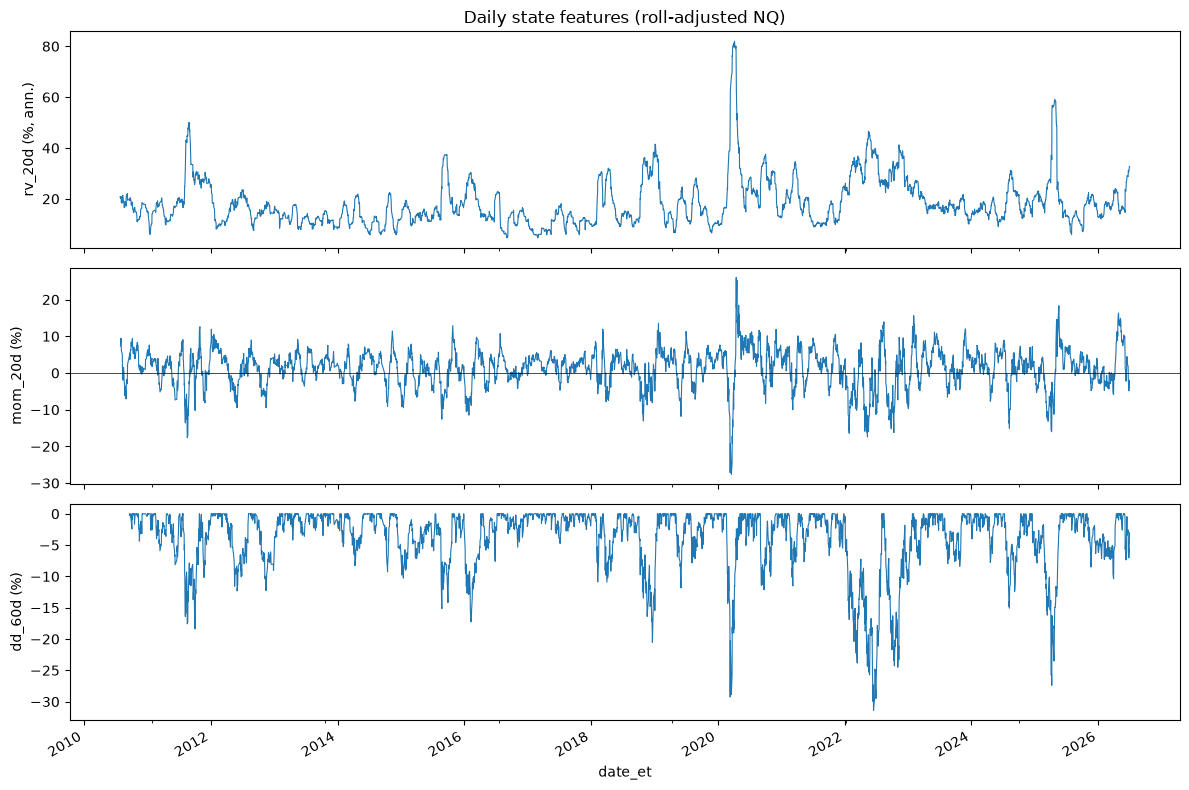

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
daily_feats["rv_20d"].plot(ax=axes[0], lw=0.8); axes[0].set_ylabel("rv_20d (%, ann.)")
daily_feats["mom_20d"].plot(ax=axes[1], lw=0.8); axes[1].axhline(0, c="k", lw=0.5); axes[1].set_ylabel("mom_20d (%)")
daily_feats["dd_60d"].plot(ax=axes[2], lw=0.8); axes[2].set_ylabel("dd_60d (%)")
axes[0].set_title(f"Daily state features (roll-adjusted {MARKET})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"nb03b_{MARKET}_daily_state_features.png", dpi=150)
plt.show()

## 5. Event-Level State Features

For each event: daily features from the previous trading day; intraday features from bars before $T$; causal percentiles (`*_pct`); and the previous same-family surprise.

This step also computes the **same-clock-time reference distribution** for intraday states, which takes a little longer (roughly a minute).

In [11]:
ev = sc.build_event_states(events, es_adj, daily, daily_feats, window_days=TRAILING_WINDOW_DAYS)

ALL_STATES = PRIMARY_STATES + EXPLORATORY_STATES
ev = sc.add_state_buckets(ev, ALL_STATES)

show_cols = ["timestamp_utc", "event_type", "x"] + [c for s in PRIMARY_STATES for c in (s, f"{s}_pct")]
display(ev[show_cols].head(10))

,timestamp_utc,event_type,x,rv_20d,rv_20d_pct,rv_pre_1d,rv_pre_1d_pct,mom_20d,mom_20d_pct,dd_60d,dd_60d_pct,overnight_ret,overnight_ret_pct,prev_x,prev_x_pct
0,2016-01-08 13:30:00+00:00,NFP,1.6143,21.8992,0.8815,204.1323,0.9698,-8.1454,0.0366,-8.6890,0.1099,90.9439,0.9440,NaN,NaN
1,2016-01-20 13:30:00+00:00,CPI,0.8034,26.2215,0.8987,213.7212,0.9655,-10.3179,0.0151,-12.4058,0.0237,-176.6938,0.0259,NaN,NaN
2,2016-02-01 13:30:00+00:00,PCE,1.3212,29.7639,0.9113,126.9112,0.7662,-8.5222,0.0498,-9.3956,0.1234,-67.6215,0.0996,NaN,NaN
3,2016-02-05 13:30:00+00:00,NFP,-0.5663,29.6667,0.8987,201.9647,0.9310,-6.3570,0.1315,-11.8337,0.0496,-17.4295,0.3147,1.6143,0.9468
4,2016-02-19 13:30:00+00:00,CPI,-1.1648,27.6333,0.8642,122.4372,0.7069,0.5436,0.5280,-12.1404,0.0711,-16.8797,0.3276,0.8034,0.7891
5,2016-02-26 15:00:00+00:00,PCE,-2.1147,24.8435,0.7780,111.0447,0.6336,2.8773,0.7866,-10.0128,0.1573,45.3009,0.7672,1.3212,0.9068
6,2016-03-04 13:30:00+00:00,NFP,0.8511,24.5463,0.7565,76.8608,0.2888,3.8056,0.8858,-8.0221,0.2694,21.3644,0.5862,-0.5663,0.2856
7,2016-03-28 12:30:00+00:00,PCE,-0.3590,16.9635,0.5196,64.6796,0.1304,4.9409,0.8891,-7.1995,0.3457,33.5047,0.6739,-2.1147,0.0172
8,2016-04-01 12:30:00+00:00,NFP,0.2326,15.4951,0.4394,71.7047,0.2121,5.5941,0.8983,-5.3845,0.4221,-35.2537,0.2208,0.8511,0.8027
9,2016-04-14 12:30:00+00:00,CPI,0.8159,14.0782,0.2737,81.7020,0.3578,5.6378,0.8944,0.0000,0.9741,-4.4000,0.4181,-1.1648,0.1221


### 5.1 No-look-ahead validation

In [12]:
checks = {}

# (a) last intraday bar used is strictly before the release, and equals the NB02 pre-event bar (T-1)
checks["asof < T (all events)"] = bool((ev["asof_utc"] < ev["timestamp_utc"]).all())
checks["asof == T-1min (share)"] = float((ev["asof_utc"] == ev["timestamp_utc"] - pd.Timedelta(minutes=1)).mean())

# (b) raw close at the as-of bar matches NB02 pre_close
raw_pre = es["close"].reindex(ev["asof_utc"]).to_numpy()
checks["close(asof) == NB02 pre_close"] = bool(np.allclose(raw_pre, ev["pre_close"], equal_nan=False))

# (c) daily features come from a date strictly before the event date
checks["feature date < event date"] = bool((pd.to_datetime(ev["feat_date_et"]) < ev["date_et"]).all())

# (d) previous close used for overnight return is before T
checks["prev close ts < T"] = bool((pd.to_datetime(ev["prev_close_ts_utc"], utc=True) < ev["timestamp_utc"]).all())

# (e) prev_x only uses earlier events of the same family
first_idx = ev.groupby("event_type")["timestamp_utc"].idxmin()
checks["first event per family has no prev_x"] = bool(ev.loc[first_idx, "prev_x"].isna().all())

display(pd.Series(checks, name="result").to_frame())
assert checks["asof < T (all events)"]
assert checks["asof == T-1min (share)"] == 1.0
assert checks["close(asof) == NB02 pre_close"]
assert checks["feature date < event date"]
assert checks["prev close ts < T"]
print("ALL NO-LOOK-AHEAD CHECKS PASSED")

,result
asof < T (all events),True
asof == T-1min (share),1.0000
close(asof) == NB02 pre_close,True
feature date < event date,True
prev close ts < T,True
first event per family has no prev_x,True


ALL NO-LOOK-AHEAD CHECKS PASSED


### 5.2 State coverage

In [13]:
coverage = pd.DataFrame({
    "raw_non_missing": [ev[s].notna().sum() for s in ALL_STATES],
    "pct_non_missing": [ev[f"{s}_pct"].notna().sum() for s in ALL_STATES],
}, index=ALL_STATES)
coverage["n_events"] = len(ev)
coverage["primary"] = coverage.index.isin(PRIMARY_STATES)
display(coverage)

,raw_non_missing,pct_non_missing,n_events,primary
rv_20d,354,354,354,True
rv_pre_1d,354,354,354,True
mom_20d,354,354,354,True
dd_60d,354,354,354,True
overnight_ret,354,354,354,True
prev_x,350,350,354,True
mom_5d,354,354,354,False
ma50_gap,354,354,354,False
rv_pre_60m,354,354,354,False
ret_pre_60m,354,354,354,False


A few events may lack a percentile. This happens when the trailing reference window has fewer than 150 observations, or for the first event of each family (`prev_x`). Those events drop out of the tests for that state only.

## 6. Post-Release Drift Returns (the Tradeable Part)

NB02 returns run from the $T-1$ close and therefore include the **instant jump**, which no strategy reacting to the number can capture. The drift return starts at the close of the first post-release bar (label $T$):

$$D_{T,h} = \ln\left(\frac{P_{T+h-1}}{P_{T}}\right)$$

Because log returns add up: $R_{T,h} = R_{T,1} + D_{T,h}$. This identity is checked below.

In [14]:
ev = sc.add_drift_returns(ev, es_adj)

for h in sc.DRIFT_HORIZONS:
    gap = (ev[f"ret_{h}m_bps"] - (ev["ret_1m_bps"] + ev[f"drift_{h}m_bps"])).abs().max()
    print(f"h={h:>2}: max |ret_h - (ret_1 + drift_h)| = {gap:.2e} bps")
    assert gap < 1e-6

display(ev.groupby("event_type")[DRIFT_TARGETS].agg(lambda v: v.abs().mean()).round(2)
        .rename(columns=lambda c: "mean|" + c + "|"))

h= 5: max |ret_h - (ret_1 + drift_h)| = 0.00e+00 bps
h=15: max |ret_h - (ret_1 + drift_h)| = 0.00e+00 bps
h=30: max |ret_h - (ret_1 + drift_h)| = 0.00e+00 bps
h=60: max |ret_h - (ret_1 + drift_h)| = 0.00e+00 bps


,mean|drift_5m_bps|,mean|drift_15m_bps|,mean|drift_30m_bps|,mean|drift_60m_bps|
event_type,,,,
CPI,16.8100,21.3100,26.3300,26.7400
NFP,12.7900,19.1700,23.9500,25.4100
PCE,7.6500,13.9500,15.3900,19.6700


## 7. State Descriptives

,rv_20d_pct,rv_pre_1d_pct,mom_20d_pct,dd_60d_pct,overnight_ret_pct,prev_x_pct
rv_20d_pct,1.0000,0.6300,-0.3900,-0.6700,-0.0700,-0.1000
rv_pre_1d_pct,0.6300,1.0000,-0.5000,-0.7500,-0.0300,-0.0200
mom_20d_pct,-0.3900,-0.5000,1.0000,0.7200,0.0600,-0.0200
dd_60d_pct,-0.6700,-0.7500,0.7200,1.0000,0.0400,0.0800
overnight_ret_pct,-0.0700,-0.0300,0.0600,0.0400,1.0000,-0.1300
prev_x_pct,-0.1000,-0.0200,-0.0200,0.0800,-0.1300,1.0000


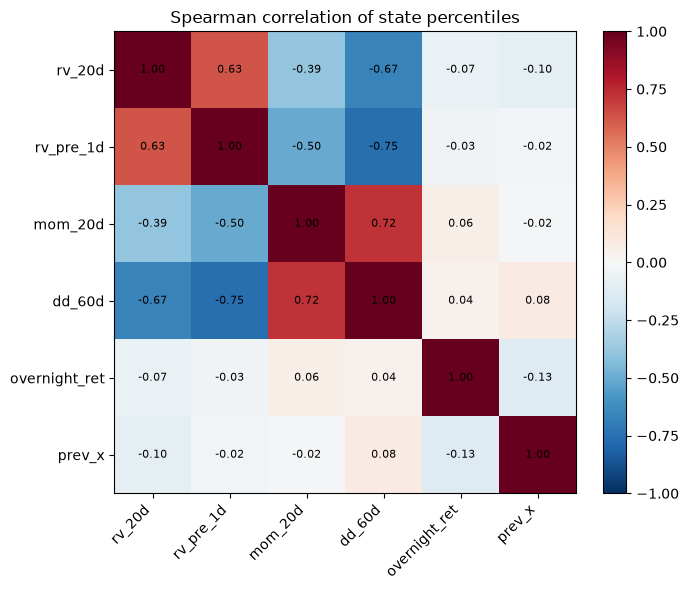

In [15]:
pct_cols = [f"{s}_pct" for s in PRIMARY_STATES]
corr = ev[pct_cols].corr(method="spearman")
display(corr.round(2))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(pct_cols))); ax.set_xticklabels(PRIMARY_STATES, rotation=45, ha="right")
ax.set_yticks(range(len(pct_cols))); ax.set_yticklabels(PRIMARY_STATES)
for i in range(len(pct_cols)):
    for j in range(len(pct_cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Spearman correlation of state percentiles")
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb03b_{MARKET}_state_correlation.png", dpi=150); plt.show()

**How to read it.** Highly correlated states (for example `rv_20d` and `dd_60d`, since drawdowns coincide with high volatility) are **not independent evidence**. If both pass, treat them as one volatility/stress regime.

In [16]:
# Bucket balance: causal terciles need not be exactly 1/3 each, since they are relative to the trailing year
bal = pd.concat({s: ev[f"{s}_bucket"].value_counts(normalize=True) for s in PRIMARY_STATES}, axis=1).T
display(bal.round(2))

# Bucket counts per family, which shows how thin the cells are
display(pd.concat({s: ev.groupby("event_type")[f"{s}_bucket"].value_counts().unstack() for s in PRIMARY_STATES}))

,Low,High,Mid
rv_20d,0.3800,0.3300,0.3000
rv_pre_1d,0.3500,0.3500,0.3000
mom_20d,0.3400,0.3300,0.3200
dd_60d,0.3600,0.3400,0.3100
overnight_ret,0.3200,0.3400,0.3400
prev_x,0.2100,0.2300,0.5500


Low  Mid  High
              event_type                
rv_20d        CPI          49   27    39
              NFP          43   39    39
              PCE          41   39    38
rv_pre_1d     CPI          49   33    33
              NFP          39   37    45
              PCE          37   35    46
mom_20d       CPI          40   38    37
              NFP          45   37    39
              PCE          37   40    41
dd_60d        CPI          38   36    41
              NFP          48   32    41
              PCE          40   40    38
overnight_ret CPI          34   39    42
              NFP          39   48    34
              PCE          39   35    44
prev_x        CPI          35   45    34
              NFP          19   77    23
              PCE          21   71    25

## 8. Bucket Analysis: Surprise Beta by State Tercile

Within each state bucket $k\in\{\text{Low},\text{Mid},\text{High}\}$:

$$r_i = a_k + \beta_k\, x_i + \varepsilon_i$$

If the state matters, $\beta$ should change **monotonically** from Low to High. Standard errors are HC3.

In [17]:
bucket = sc.bucket_betas(ev, ALL_STATES, FAMILIES, ALL_TARGETS)
bucket.to_csv(RESULTS_DIR / f"nb03b_{MARKET}_bucket_betas.csv", index=False)

cpi_view = (
    bucket[(bucket["family"] == "CPI") & bucket["state"].isin(PRIMARY_STATES) & bucket["target"].isin(PRIMARY_TARGETS)]
    .pivot_table(index=["state", "target"], columns="bucket", values="beta")
    [["Low", "Mid", "High"]]
)
cpi_view["High - Low"] = cpi_view["High"] - cpi_view["Low"]
print("CPI: surprise beta (bps per 1-SD good-news surprise) by state bucket")
display(cpi_view.round(2))

CPI: surprise beta (bps per 1-SD good-news surprise) by state bucket


bucket                          Low     Mid    High  High - Low
state         target                                           
dd_60d        drift_30m_bps  7.6400 17.2900  4.2400     -3.4000
              ret_5m_bps    41.6900 38.9700 23.8800    -17.8100
mom_20d       drift_30m_bps  4.3700 19.6600  7.2800      2.9100
              ret_5m_bps    36.4400 59.3000 23.8700    -12.5800
overnight_ret drift_30m_bps -1.2400  9.6400 20.0400     21.2800
              ret_5m_bps    15.7100 27.9600 75.9100     60.2000
prev_x        drift_30m_bps  8.0900  9.7200 12.7800      4.6900
              ret_5m_bps    39.7400 34.6200 33.5600     -6.1800
rv_20d        drift_30m_bps  1.1900 25.9000 13.1200     11.9400
              ret_5m_bps    18.4400 70.0100 58.3100     39.8800
rv_pre_1d     drift_30m_bps  8.8100 19.7800  2.8500     -5.9600
              ret_5m_bps    32.9500 58.6100 29.5200     -3.4300

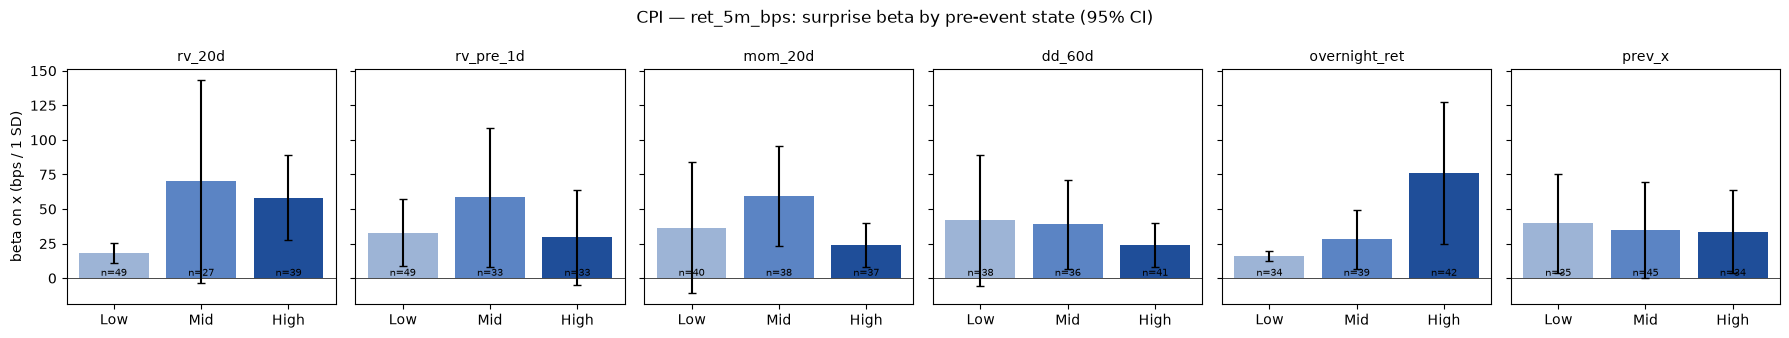

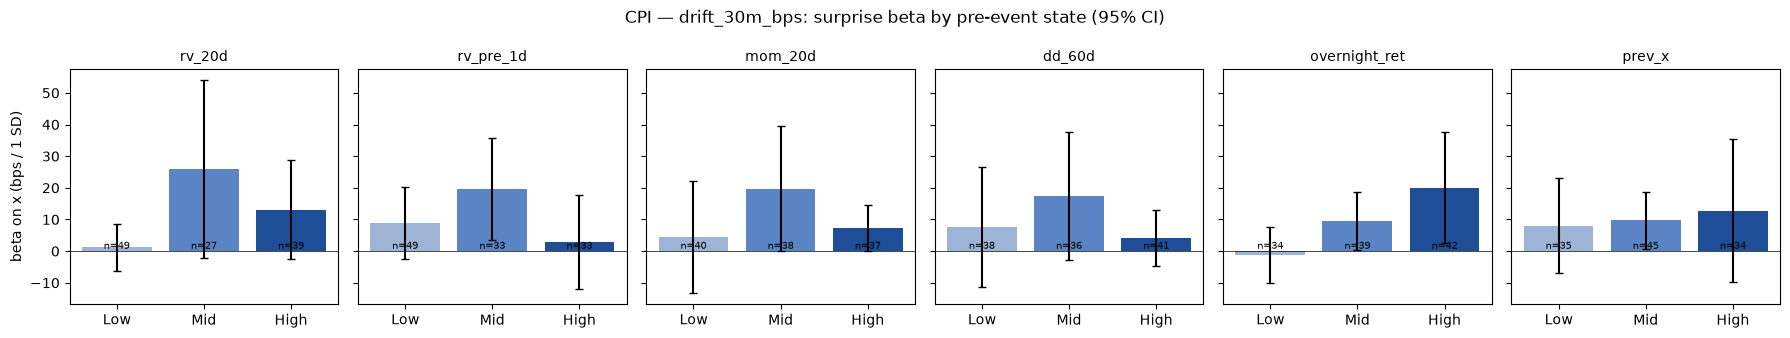

In [18]:
def plot_bucket_betas(bucket, family, target, states, fname):
    sub = bucket[(bucket.family == family) & (bucket.target == target) & bucket.state.isin(states)]
    fig, axes = plt.subplots(1, len(states), figsize=(3.0 * len(states), 3.4), sharey=True)
    for ax, s in zip(np.atleast_1d(axes), states):
        d = sub[sub.state == s].set_index("bucket").reindex(["Low", "Mid", "High"])
        ax.bar(d.index, d["beta"], yerr=1.96 * d["se"], capsize=3, color=["#9db4d6", "#5b84c4", "#1f4e99"])
        ax.axhline(0, c="k", lw=0.5)
        ax.set_title(s, fontsize=10)
        for k, (b, n) in enumerate(zip(d["beta"], d["n"])):
            if np.isfinite(b):
                ax.text(k, 0, f"n={int(n)}", ha="center", va="bottom", fontsize=7)
    np.atleast_1d(axes)[0].set_ylabel("beta on x (bps / 1 SD)")
    fig.suptitle(f"{family} — {target}: surprise beta by pre-event state (95% CI)")
    plt.tight_layout(); plt.savefig(FIGURES_DIR / fname, dpi=150); plt.show()

for tgt in PRIMARY_TARGETS:
    plot_bucket_betas(bucket, "CPI", tgt, PRIMARY_STATES, f"nb03b_{MARKET}_cpi_bucket_betas_{tgt}.png")

**How to read it.** Wide error bars are expected, since each CPI bucket holds about 40 events. Look for a **monotone** Low → Mid → High pattern that repeats across both targets. A single tall bar is not evidence on its own.

## 9. Interaction Regressions

Using the full sample in one regression is more efficient than splitting it into buckets:

$$r_i = a + b\,x_i + c\,s_i + d\,(x_i \times s_i) + \varepsilon_i, \qquad s_i = \text{pct}_i - 0.5$$

- $b$: surprise beta at the **median** state
- $c$: does the state predict the return on its own (direction)?
- $d$: **the key coefficient**, the change in surprise beta from the lowest to the highest state percentile

Since $x$ is signed so that $b>0$, a **positive $d$** means *a stronger reaction in the high state*.
The pooled (`ALL`) model has family-specific intercepts and slopes and a common $c$ and $d$.

In [19]:
inter = sc.interaction_tests(ev, ALL_STATES, FAMILIES, ALL_TARGETS,
                             n_perm=N_PERM, perm_targets=PRIMARY_TARGETS)
inter["primary_state"] = inter["state"].isin(PRIMARY_STATES)

# FDR is applied to the PRIMARY family of tests only (primary states x families x primary targets)
prim_mask = inter["primary_state"] & inter["target"].isin(PRIMARY_TARGETS)
inter["q_bh_primary"] = np.nan
inter.loc[prim_mask, "q_bh_primary"] = sc.bh_fdr(inter.loc[prim_mask, "p_interact"])
inter.to_csv(RESULTS_DIR / f"nb03b_{MARKET}_interaction_results.csv", index=False)

print("Number of primary tests (FDR family):", prim_mask.sum())
display(
    inter[prim_mask]
    .sort_values("p_interact")
    [["state", "family", "target", "n", "b_x", "d_interact", "t_interact", "p_interact", "p_perm", "q_bh_primary", "r2"]]
    .round(4)
)

Number of primary tests (FDR family): 48


,state,family,target,n,b_x,d_interact,t_interact,p_interact,p_perm,q_bh_primary,r2
1,rv_20d,CPI,ret_5m_bps,115,44.7148,57.6363,2.9638,0.0037,0.0090,0.1785,0.3687
145,overnight_ret,CPI,ret_5m_bps,115,38.9693,83.0822,2.4248,0.0169,0.0330,0.4063,0.4300
151,overnight_ret,CPI,drift_30m_bps,115,9.2966,29.8413,2.0824,0.0396,0.0460,0.6337,0.1285
70,rv_pre_1d,ALL,drift_30m_bps,353,NaN,-9.7065,-1.7050,0.0891,0.0435,0.8919,0.0535
106,mom_20d,ALL,drift_30m_bps,353,NaN,5.3825,1.5353,0.1256,0.0625,0.8919,0.0376
7,rv_20d,CPI,drift_30m_bps,115,11.3288,19.6113,1.5329,0.1281,0.1414,0.8919,0.1084
97,mom_20d,PCE,drift_30m_bps,118,-1.8563,19.3511,1.5248,0.1301,0.1319,0.8919,0.0590
109,dd_60d,CPI,ret_5m_bps,115,33.5413,-39.5341,-1.3433,0.1819,0.1974,0.9723,0.3320
133,dd_60d,PCE,drift_30m_bps,118,-1.6799,15.9492,1.2490,0.2142,0.2064,0.9723,0.0443
52,rv_pre_1d,NFP,drift_30m_bps,120,0.6032,-8.6580,-1.2445,0.2158,0.1419,0.9723,0.0238


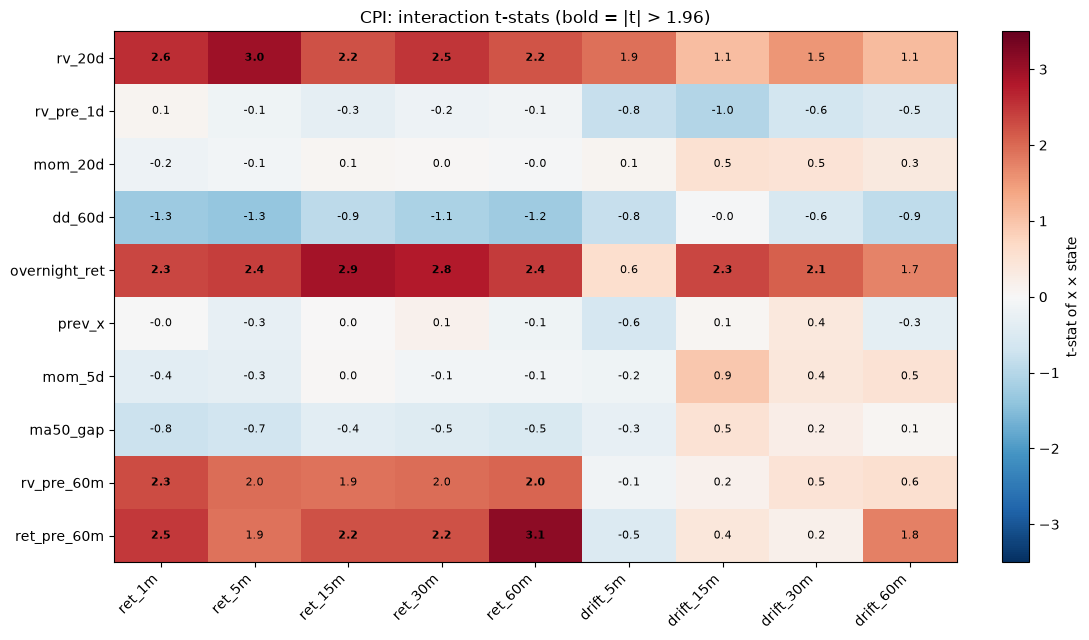

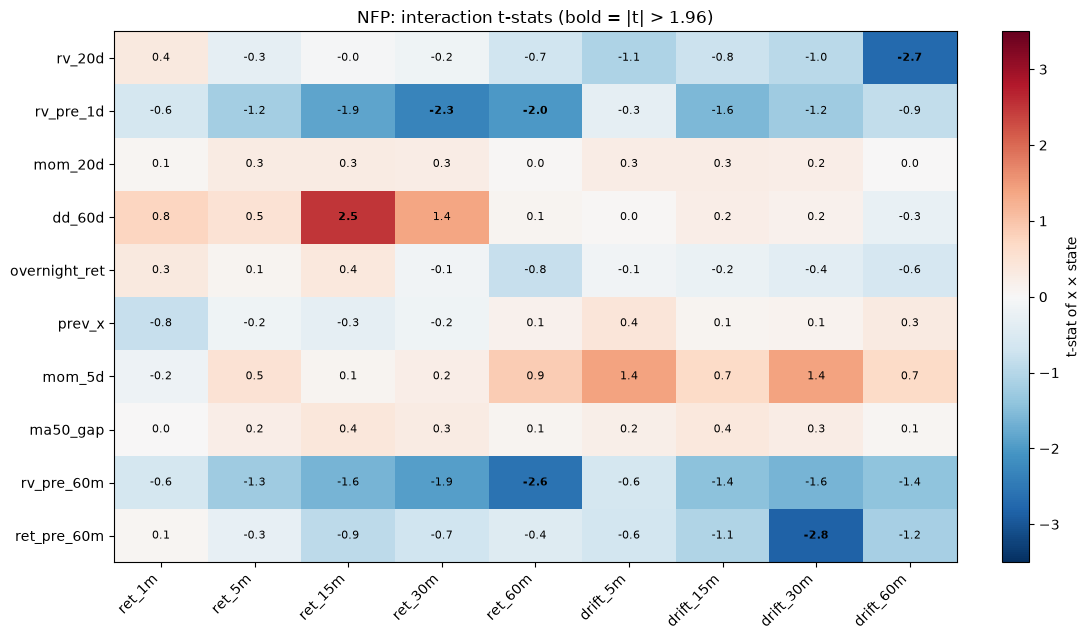

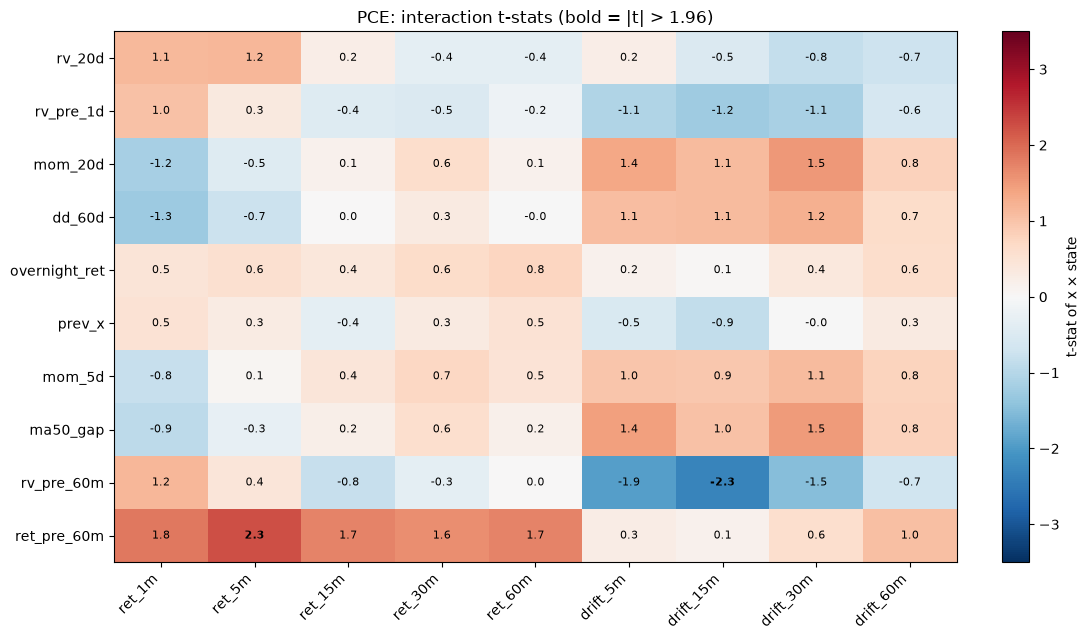

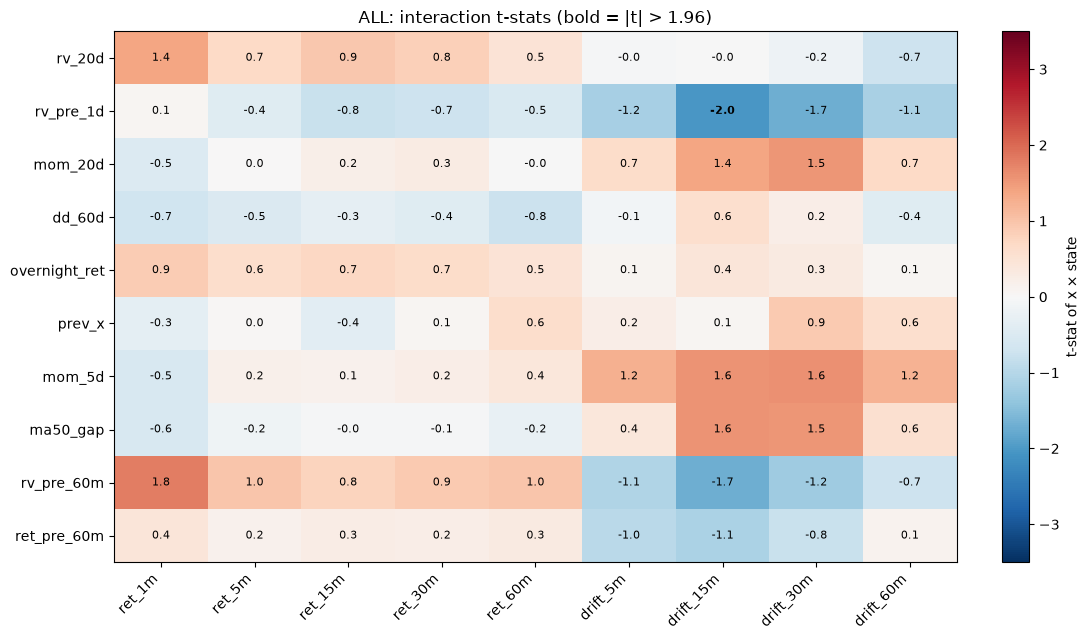

In [20]:
def tstat_heatmap(inter, family, states, targets, fname):
    m = (inter[(inter.family == family) & inter.state.isin(states)]
         .pivot_table(index="state", columns="target", values="t_interact")
         .reindex(index=states, columns=targets))
    fig, ax = plt.subplots(figsize=(1.0 * len(targets) + 2, 0.5 * len(states) + 1.5))
    im = ax.imshow(m.values, cmap="RdBu_r", vmin=-3.5, vmax=3.5, aspect="auto")
    ax.set_xticks(range(len(targets))); ax.set_xticklabels([t.replace("_bps", "") for t in targets], rotation=45, ha="right")
    ax.set_yticks(range(len(states))); ax.set_yticklabels(states)
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            v = m.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8,
                        fontweight="bold" if abs(v) > 1.96 else "normal")
    plt.colorbar(im, ax=ax, fraction=0.03, label="t-stat of x × state")
    ax.set_title(f"{family}: interaction t-stats (bold = |t| > 1.96)")
    plt.tight_layout(); plt.savefig(FIGURES_DIR / fname, dpi=150); plt.show()

for fam in FAMILIES:
    tstat_heatmap(inter, fam, ALL_STATES, ALL_TARGETS, f"nb03b_{MARKET}_interaction_tstats_{fam}.png")

**How to read it.** A credible state effect looks like a **row of same-coloured cells** across horizons. A single bold cell among about 90 is what chance alone produces: at 5% significance, roughly 4–5 false positives are expected.

## 10. Permutation Tests and Multiple-Testing Control

- **Permutation p-value.** The state percentile is shuffled across events *within each family* 2,000 times. This breaks any link between the state and the surprise while keeping each family's returns intact. It makes no normality assumption.
- **BH-FDR q-value.** This controls the expected share of false discoveries across the primary tests.

,count
primary tests,48.0000
expected false positives at 5% (if no true effect),2.4000
naive p < 0.05,3.0000
permutation p < 0.05,4.0000
BH q < 0.1,0.0000


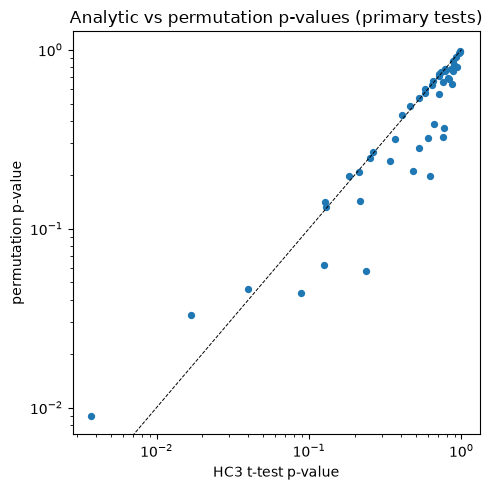

In [21]:
pt = inter[prim_mask].copy()
pt["sig_naive_5pct"] = pt["p_interact"] < 0.05
pt["sig_perm_5pct"] = pt["p_perm"] < 0.05
pt["sig_fdr"] = pt["q_bh_primary"] < FDR_Q

summary_mt = pd.Series({
    "primary tests": len(pt),
    "expected false positives at 5% (if no true effect)": round(0.05 * len(pt), 1),
    "naive p < 0.05": int(pt["sig_naive_5pct"].sum()),
    "permutation p < 0.05": int(pt["sig_perm_5pct"].sum()),
    f"BH q < {FDR_Q}": int(pt["sig_fdr"].sum()),
})
display(summary_mt.to_frame("count"))

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pt["p_interact"], pt["p_perm"], s=18)
ax.plot([0, 1], [0, 1], "k--", lw=0.7)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("HC3 t-test p-value"); ax.set_ylabel("permutation p-value")
ax.set_title("Analytic vs permutation p-values (primary tests)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb03b_{MARKET}_pvalue_comparison.png", dpi=150); plt.show()

If the number of naive "significant" results is close to the expected false-positive count, the evidence for state dependence is weak **as a whole**, even if individual p-values look good.

## 11. Subperiod Stability

The sample spans two very different inflation regimes: low and stable in 2016–2020, then the 2021+ inflation shock and hiking cycle. A usable state effect should keep its sign in both.

In [22]:
stab = sc.subperiod_stability(ev, ALL_STATES, FAMILIES, ALL_TARGETS, split_date=SPLIT_DATE)
stab.to_csv(RESULTS_DIR / f"nb03b_{MARKET}_subperiod_stability.csv", index=False)

display(
    stab[stab.state.isin(PRIMARY_STATES) & stab.target.isin(PRIMARY_TARGETS)]
    .sort_values(["family", "state", "target"])
    .round(3)
)

share = (stab[stab.state.isin(PRIMARY_STATES)]
         .groupby(["family", "state"])["same_sign"].mean().unstack("family").round(2))
print("Share of horizons with the same interaction sign in both subperiods:")
display(share)

,state,family,target,n_early,d_interact_early,t_interact_early,n_late,d_interact_late,t_interact_late,same_sign
142,dd_60d,ALL,drift_30m_bps,167,1.0330,0.1770,186,0.5110,0.0390,True
136,dd_60d,ALL,ret_5m_bps,167,-0.4760,-0.0570,186,-25.0990,-0.7500,True
106,mom_20d,ALL,drift_30m_bps,167,3.6700,0.9420,186,9.5040,0.6700,True
100,mom_20d,ALL,ret_5m_bps,167,-1.7500,-0.1140,186,2.0620,0.0380,False
178,overnight_ret,ALL,drift_30m_bps,167,-0.6930,-0.0820,186,23.3910,1.6320,False
172,overnight_ret,ALL,ret_5m_bps,167,2.4780,0.2500,186,74.3880,2.4810,True
214,prev_x,ALL,drift_30m_bps,164,1.4530,0.7480,185,-8.3750,-0.4800,False
208,prev_x,ALL,ret_5m_bps,164,0.1280,0.0580,185,-0.7370,-0.0250,False
34,rv_20d,ALL,drift_30m_bps,167,-4.7750,-1.0830,186,13.4210,0.9850,False
28,rv_20d,ALL,ret_5m_bps,167,-0.0670,-0.0110,186,63.4800,2.5900,False


Share of horizons with the same interaction sign in both subperiods:


family,ALL,CPI,NFP,PCE
state,,,,
dd_60d,0.6700,0.8900,0.3300,0.5600
mom_20d,0.6700,0.2200,0.5600,0.6700
overnight_ret,0.5600,0.7800,0.4400,0.2200
prev_x,0.2200,0.7800,0.3300,0.0000
rv_20d,0.2200,0.8900,0.3300,0.4400
rv_pre_1d,0.8900,0.0000,0.6700,0.6700


## 12. Does the State Predict the *Size* of the Move?

Even if the state does not change the *direction* coefficient, it may predict **how big** the move is, which matters for position sizing and risk limits in Notebook 04:

$$|r_i| = a + g\,|x_i| + h\,s_i + \varepsilon_i$$

In [23]:
mag = sc.magnitude_tests(ev, ALL_STATES, FAMILIES, ALL_TARGETS)
mag.to_csv(RESULTS_DIR / f"nb03b_{MARKET}_magnitude_results.csv", index=False)

display(
    mag[mag.state.isin(PRIMARY_STATES) & mag.target.isin(["ret_5m_bps", "ret_30m_bps", "drift_30m_bps"])]
    .sort_values("p_state")
    .round(4)
    .head(20)
)

,state,family,target,n,r2,g_abs_x,h_state,t_state,p_state,q_bh
142,dd_60d,ALL,drift_30m_bps,353,0.0802,0.0513,-22.5653,-4.7606,0.0000,0.0001
34,rv_20d,ALL,drift_30m_bps,353,0.0561,-0.0420,18.0585,4.1985,0.0000,0.0010
106,mom_20d,ALL,drift_30m_bps,353,0.0362,0.0937,-15.5274,-3.5071,0.0005,0.0080
70,rv_pre_1d,ALL,drift_30m_bps,353,0.0336,-0.0546,14.4804,3.3171,0.0010,0.0128
147,overnight_ret,CPI,ret_30m_bps,115,0.1905,24.7821,91.4318,3.3620,0.0011,0.0128
124,dd_60d,NFP,drift_30m_bps,120,0.1136,-0.0445,-24.7366,-3.2702,0.0014,0.0159
136,dd_60d,ALL,ret_5m_bps,353,0.0331,0.2106,-26.2401,-3.1366,0.0019,0.0171
165,overnight_ret,PCE,ret_30m_bps,118,0.1146,2.7818,-24.9375,-3.0248,0.0031,0.0232
133,dd_60d,PCE,drift_30m_bps,118,0.1199,1.7879,-22.2637,-2.9817,0.0035,0.0247
138,dd_60d,ALL,ret_30m_bps,353,0.0269,-0.0160,-27.6810,-2.8250,0.0050,0.0297


**Expected pattern.** Volatility states (`rv_20d`, `rv_pre_1d`) usually show a strong positive $h$: in high-vol regimes, moves are bigger regardless of the surprise. That is useful for **risk scaling** even if it does not improve the **directional** signal.

## 13. Pre-Registered Selection Rule and Hand-off to Notebook 04

A (state, family) pair is carried into Notebook 04 only if, on a primary target, it passes **all** of these:

1. BH-FDR q < 0.10 (primary test family)
2. permutation p < 0.05
3. the interaction has the same sign in 2016–2020 and in 2021–2026
4. the interaction sign agrees on at least 60% of all nine targets

If nothing passes, Notebook 04 uses the **surprise-only** model as the main strategy, and state is used only for risk scaling (Section 12), if at all.

In [24]:
inter_primary = inter[prim_mask].copy()
inter_primary["q_bh"] = inter_primary["q_bh_primary"]   # use the primary-family FDR
all_for_agreement = inter[inter.state.isin(PRIMARY_STATES)].copy()

# horizon agreement uses ALL targets; significance uses the primary targets only
sel = sc.select_states(
    pd.concat([inter_primary, all_for_agreement[~all_for_agreement.index.isin(inter_primary.index)]]),
    stab, PRIMARY_TARGETS, q_max=FDR_Q,
)
sel.to_csv(RESULTS_DIR / f"nb03b_{MARKET}_state_selection.csv", index=False)

display(sel[["state", "family", "target", "n", "d_interact", "t_interact", "p_perm", "q_bh",
             "same_sign", "horizon_sign_agreement",
             "pass_fdr", "pass_perm", "pass_stability", "pass_horizons", "selected"]].round(3))

selected_pairs = sel.loc[sel["selected"], ["state", "family"]].drop_duplicates()
print("\nSELECTED (state, family) pairs for Notebook 04:")
print(selected_pairs.to_string(index=False) if len(selected_pairs) else "  none. Use surprise-only as the main model.")

,state,family,target,n,d_interact,t_interact,p_perm,q_bh,same_sign,horizon_sign_agreement,pass_fdr,pass_perm,pass_stability,pass_horizons,selected
0,rv_20d,CPI,ret_5m_bps,115,57.6360,2.9640,0.0090,0.1790,True,1.0000,False,True,True,True,False
32,overnight_ret,CPI,ret_5m_bps,115,83.0820,2.4250,0.0330,0.4060,True,1.0000,False,True,True,True,False
33,overnight_ret,CPI,drift_30m_bps,115,29.8410,2.0820,0.0460,0.6340,False,1.0000,False,True,False,True,False
1,rv_20d,CPI,drift_30m_bps,115,19.6110,1.5330,0.1410,0.8920,True,1.0000,False,False,True,True,False
15,rv_pre_1d,ALL,drift_30m_bps,353,-9.7070,-1.7050,0.0430,0.8920,True,0.8890,False,True,True,True,False
21,mom_20d,PCE,drift_30m_bps,118,19.3510,1.5250,0.1320,0.8920,True,0.7780,False,False,True,True,False
23,mom_20d,ALL,drift_30m_bps,353,5.3820,1.5350,0.0620,0.8920,True,0.7780,False,False,True,True,False
4,rv_20d,PCE,ret_5m_bps,118,7.8630,1.1520,0.2480,0.9720,False,0.5560,False,False,False,False,False
10,rv_pre_1d,NFP,ret_5m_bps,120,-12.5910,-1.1920,0.0580,0.9720,True,1.0000,False,False,True,True,False
11,rv_pre_1d,NFP,drift_30m_bps,120,-8.6580,-1.2440,0.1420,0.9720,True,1.0000,False,False,True,True,False



SELECTED (state, family) pairs for Notebook 04:
  none. Use surprise-only as the main model.


### 13.1 Save the event state dataset for Notebook 04

In [25]:
keep = (
    ["timestamp_utc", "event_type", "date_et", "clock_et", "asof_utc", "feat_date_et", "x", "abs_x", "pre_close"]
    + [c for c in events.columns if c.startswith("ret_")]
    + DRIFT_TARGETS
    + [c for s in ALL_STATES for c in (s, f"{s}_pct", f"{s}_bucket")]
    + ["prev_x"]
    + ["avg_hourly_earnings", "core_cpi", "core_pce", "headline_cpi", "headline_pce", "nonfarm_payrolls", "unemployment_rate"]
)
keep = list(dict.fromkeys(c for c in keep if c in ev.columns))
state_out = ev[keep].copy()
for s in ALL_STATES:
    state_out[f"{s}_bucket"] = state_out[f"{s}_bucket"].astype(str)

STATE_FILE = PROCESSED_DIR / f"event_state_features_2016_2026_{MARKET}.parquet"
state_out.to_parquet(STATE_FILE, index=False)
state_out.to_csv(PROCESSED_DIR / f"event_state_features_2016_2026_{MARKET}.csv", index=False)

check = pd.read_parquet(STATE_FILE)
assert len(check) == len(events)
assert check["timestamp_utc"].is_unique
print("Saved:", STATE_FILE, check.shape)

Saved: /Users/reza/Desktop/mfe-term_3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises/data/processed/event_state_features_2016_2026_NQ.parquet (354, 55)


### 13.2 Final validation and results summary

In [26]:
print("=" * 78)
print("NOTEBOOK 03 SUMMARY")
print("=" * 78)
print(f"Events: {len(ev)}  ({ev['timestamp_utc'].min().date()} to {ev['timestamp_utc'].max().date()})")
print(f"Primary states: {len(PRIMARY_STATES)}   Primary targets: {PRIMARY_TARGETS}")
print(f"Primary interaction tests: {len(pt)}  |  naive p<0.05: {int(pt['sig_naive_5pct'].sum())}"
      f"  |  perm p<0.05: {int(pt['sig_perm_5pct'].sum())}  |  BH q<{FDR_Q}: {int(pt['sig_fdr'].sum())}")

best = pt.sort_values("p_interact").head(5)[["state", "family", "target", "d_interact", "t_interact", "p_perm", "q_bh_primary"]]
print("\nStrongest primary interactions:")
print(best.round(3).to_string(index=False))

mag_best = (mag[mag.state.isin(PRIMARY_STATES) & (mag.target == "ret_5m_bps")]
            .sort_values("p_state").head(5)[["state", "family", "h_state", "t_state", "q_bh"]])
print("\nStrongest magnitude (|return|) effects, ret_5m:")
print(mag_best.round(3).to_string(index=False))

print("\nSelected for NB04:", selected_pairs.values.tolist() if len(selected_pairs) else "none (surprise-only baseline)")
print("\nOutputs:")
for f in [f"nb03b_{MARKET}_bucket_betas.csv", f"nb03b_{MARKET}_interaction_results.csv", f"nb03b_{MARKET}_subperiod_stability.csv",
          f"nb03b_{MARKET}_magnitude_results.csv", f"nb03b_{MARKET}_state_selection.csv"]:
    print("  results/" + f)
print(f"  data/processed/event_state_features_2016_2026_{MARKET}.parquet")

NOTEBOOK 03 SUMMARY
Events: 354  (2016-01-08 to 2026-06-25)
Primary states: 6   Primary targets: ['ret_5m_bps', 'drift_30m_bps']
Primary interaction tests: 48  |  naive p<0.05: 3  |  perm p<0.05: 4  |  BH q<0.1: 0

Strongest primary interactions:
        state family        target  d_interact  t_interact  p_perm  q_bh_primary
       rv_20d    CPI    ret_5m_bps     57.6360      2.9640  0.0090        0.1790
overnight_ret    CPI    ret_5m_bps     83.0820      2.4250  0.0330        0.4060
overnight_ret    CPI drift_30m_bps     29.8410      2.0820  0.0460        0.6340
    rv_pre_1d    ALL drift_30m_bps     -9.7070     -1.7050  0.0430        0.8920
      mom_20d    ALL drift_30m_bps      5.3820      1.5350  0.0620        0.8920

Strongest magnitude (|return|) effects, ret_5m:
        state family  h_state  t_state   q_bh
       dd_60d    ALL -26.2400  -3.1370 0.0170
overnight_ret    CPI  65.7180   2.6050 0.0450
      mom_20d    ALL -20.0000  -2.4920 0.0540
       dd_60d    CPI -48.9420  -2.

## 14. Interpretation and Conclusion

*Fill this in after running, using the summary above. Suggested structure:*

**1. Directional state dependence.** Which primary states, if any, changed the surprise beta for CPI? Give the sign and size of $d$ in bps, and whether the effect held up after FDR, permutation, and subperiod checks.

**2. Magnitude.** Did volatility states predict larger absolute moves? That is useful for sizing even when direction is unaffected.

**3. Instant response vs drift.** Does state matter more for the instant jump (`ret_5m`) or for the tradeable post-release drift (`drift_30m`)? Only the latter can be monetised.

**4. Implication for Notebook 04.**
- *Surprise only:* trade the sign of $x$ (CPI first), entering at the $T$ bar close.
- *Surprise + state:* use the selected state(s) to scale or filter trades.
- If no state passed, say so plainly. A null result from a pre-registered, look-ahead-free test is a credible finding, and far better than a data-mined one.

**Caveats.** There are about 120 events per family, so buckets hold about 40 events. States are correlated (volatility and drawdown). And the 2021+ inflation regime dominates CPI's economic significance.

# 14. Purpose, Research Questions, and Answers (NQ)

## Purpose of Notebook 03b (NQ)

Notebook 03 showed for ES that the reaction to a CPI surprise depends on the market's state before the release, mainly 20-day volatility. Notebook 02b showed that NQ (Nasdaq-100 futures) reacts to CPI even more strongly than ES.

Notebook 03b repeats the full Notebook 03 analysis on **NQ**, with the same code, states, tests and selection rule. It asks:

> **Does NQ's reaction to the same surprise depend on the pre-release state, and is it the same state as in ES?**

- If **yes**, the state can be used for NQ in Notebook 04b.
- If **no**, the surprise-only strategy is the NQ benchmark.

---

## Research Questions and Answers

### Section 2: Is the surprise signal defined correctly for NQ?
**Question:** Using the same signed surprise $x$ as for ES ($x>0$ = good news for equities), is $x$ related to NQ returns in the expected direction?

**Answer:** Yes. The correlation between $x$ and the 5-minute NQ return is **0.54 for CPI**, **0.32 for PCE**, and **0.03 for NFP**. This is almost identical to ES: CPI is the strongest signal, PCE second, and NFP has no directional relation. NQ has 354 of the 363 releases; 9 have no NQ price data around the release.

### Section 3: Can we trust multi-day features from a continuous futures series?
**Question:** The continuous NQ series jumps at every quarterly roll. Would these jumps contaminate momentum and drawdown?

**Answer:** They would have. **64 rolls** were detected, with jumps from **−743 to +467 bps**, larger than in ES. The roll-adjusted series removes them while leaving within-contract returns exactly unchanged (maximum difference = 0).

### Section 4: What did NQ's daily state look like from 2010 to 2026?
**Question:** Do the daily state variables behave sensibly?

**Answer:** Yes. The 20-day realised volatility of NQ has a median of about **16%** (ES: about 13%) and peaks at about **82%**. The 60-day drawdown reaches **−31%**. NQ is a more volatile version of ES, and the same market regimes are visible.

### Section 5: Are the state variables free of look-ahead bias?
**Question:** Does any state variable use information available only after the release?

**Answer:** No. **All look-ahead checks passed.** Every feature uses data up to the $T-1$ bar, and daily features come from the previous trading day's close.

### Section 6: How much of the reaction is actually tradeable?
**Question:** How much of NQ's reaction remains after the first minute?

**Answer:** More than in ES. For CPI, the 30-minute post-release drift averages about **26 bps in absolute size** (ES: about 20). Its sensitivity to the surprise is about **8.5 bps per 1-SD surprise**, compared with about **37 bps** for the full 5-minute response. As in ES, most of the reaction is immediate, but a tradeable part remains.

### Section 7: Are the state variables distinct from each other?
**Question:** Are we measuring six different states, or the same state six times?

**Answer:** As in ES, they partly overlap. Volatility and drawdown are strongly correlated (Spearman **−0.67 to −0.75**), and momentum and drawdown **+0.72**, so together they describe one **stress regime**. The overnight return and the previous surprise are largely independent.

### Section 8: Does the surprise beta differ across Low, Mid, and High states?
**Question:** If CPI releases are split into terciles by pre-event state, does the 5-minute response to the same surprise change?

**Answer:**
- **20-day volatility:** yes, as in ES. The CPI beta is about **18 bps** in the low-volatility tercile, compared with **58–70 bps** in the mid and high terciles.
- **Overnight return:** the CPI beta rises monotonically, **16 → 28 → 76 bps**, the same pattern as in ES.
- **Drawdown:** the beta is smaller near the 60-day high (**42 → 24 bps**).
- **Other states:** no clear pattern.

### Section 9: Is the state effect statistically significant?
**Question:** In the regression $r = a + b\,x + c\,s + d\,(x \times s)$, is the interaction coefficient $d$ significant?

**Answer:**
- **CPI × 20-day volatility** is again the strongest effect on the 5-minute response (**t = 3.0**). Moving from the calmest to the most volatile conditions raises the CPI beta by about **58 bps** (ES: t = 3.8, about 61 bps).
- **CPI × overnight return** is also positive (**t = 2.4** on the 5-minute response, **t = 2.1** on the 30-minute drift).
- **NFP × volatility**, significant in ES, shows **no effect** in NQ.

### Section 10: Could these results be luck from running many tests?
**Question:** With 48 primary tests, how many survive proper correction?

**Answer:** About **2.4** false positives are expected by chance; **3** tests are significant before correction (4 by permutation). After Benjamini–Hochberg FDR correction, **none survive**. The strongest test, CPI × volatility, reaches q = 0.18. The NQ evidence is weaker than in ES, where two tests survived.

### Section 11: Is the effect stable over time?
**Question:** Does the effect hold in both 2016–2020 and 2021–2026?

**Answer:** Only partially, exactly as in ES.
- **CPI × volatility** has the same sign in both periods, but is significant **only after 2021** (t = 1.2 → 2.3).
- **CPI × overnight return** is also a post-2021 effect (t = 0.7 → 3.3), and on the 30-minute drift it changes sign between the periods.

### Section 12: Does the state predict the size of the move?
**Question:** Setting direction aside, are NQ moves larger in certain states?

**Answer:** **Yes. As in ES, this is the most robust finding.** **154 of 360** magnitude tests survive FDR correction. In high 20-day volatility the absolute 30-minute drift is about **18 bps larger** (t = 4.2), and it is about **23 bps larger** in a deep drawdown than near the 60-day high (t = −4.8).

### Section 13: Which states are carried into Notebook 04b?
**Question:** Which (state, family) pairs pass all four pre-registered criteria: FDR, permutation, subperiod stability, and horizon consistency?

**Answer:** **None.** CPI × volatility passes the permutation, stability and horizon tests, but fails the FDR test (q = 0.18).

---

## Overall Conclusion

NQ repeats the ES picture, with weaker statistics:

1. **Direction:** CPI surprises move NQ much more when 20-day volatility is elevated. The effect has the same sign and a similar size to ES (+58 vs +61 bps), but it does not survive multiple-testing correction and it is concentrated in 2021–2026.
2. **Size:** volatility and drawdown strongly predict **how large** the NQ move will be (154 of 360 tests survive FDR), independent of the surprise.

## Implications for Notebook 04b (NQ)

| Model | Specification |
|---|---|
| **Surprise only** (baseline) | Trade the sign of the CPI surprise at the close of the first post-release minute, hold 30 minutes |
| **Surprise + State** | Uses `rv_20d`, the state selected for **ES**. This tests whether the ES state rule carries over to NQ, not a state selected on NQ |
| **NFP** | No directional relation in NQ ($\text{corr} = 0.03$); not a candidate for directional trading |

**Caveats:** about 115–120 events per family (about 40 per tercile), no state passes FDR on NQ, and, as in ES, the CPI effect is concentrated in the post-2021 inflation regime.